# PedSilicoICH: Part 1. Phantoms

This notebook introduces the features and uses of the PedSilicoICH tool for generating anthropomorphic ground truth phantoms - currently based on the MIDA phantom and NIHPD MR brain atlases as a base - with models of intracranial hemorrhage, specifically intraparenchymal (IPH), epiural (EDH), and subural (SDH) hemorrages.liver metastases.

This notebook also introduces concepts of the `Phantoms` Class

In [23]:
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

## Select a starting phantom

In [24]:
import insilicoICH
import VITools
available_phantoms = VITools.get_available_phantoms()
available_phantoms

{'0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/NIHPD_Head_Phantom/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/NIHPD_Head_Phantom/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/NIHPD_Head_Phantom/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/NIHPD_Head_Phantom/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIH

In [25]:
phantom = available_phantoms['6.5 yr NIHPD Head']()
phantom.add_fracture=True
# phantom.resize(3*[240]) NOTE_K: keeping original size
# phantom.insert_lesion('EDH', mass_effect=True, seed=42, intensity=80, volume=5, edema=1)

pseudo-CT images not found; defaulting to otsu segmentation method
assign_HUs: adding fractures
Reading /home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/insilicoICH/annotations/skull/NIHPD_Head_Phantom/assets/config.toml
assign_HUs: adding fractures
Reading /home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/insilicoICH/annotations/skull/NIHPD_Head_Phantom/assets/config.toml


In [26]:
%pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [27]:
import matplotlib.pyplot as plt
from utils import scrollview

scrollview(phantom.get_CT_number_phantom())

assign_HUs: adding fractures
Reading /home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/insilicoICH/annotations/skull/NIHPD_Head_Phantom/assets/config.toml


interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

## define a set of lesions to insert
This can be done individual or arranged into a list if inserting multiple as demonstrated here.

In [28]:
import numpy as np
volumes = np.linspace(0.05, 0.5, 3)
intensities = np.linspace(70, 50, 3)
lesion_type = 'IPH'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)
lesions

[{'volume': 0.05, 'intensity': 70.0, 'lesion_type': 'IPH', 'seed': 336},
 {'volume': 0.275, 'intensity': 60.0, 'lesion_type': 'IPH', 'seed': 336},
 {'volume': 0.5, 'intensity': 50.0, 'lesion_type': 'IPH', 'seed': 336}]

## Insert the lesions into the selected phantom

In [29]:
# NOTE_K: not using insert_lesion; else it will return self._phantom from get_CT_number_phantom from head_phantoms.py:507
# for idx, lesion in enumerate(lesions):
#     print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
#     phantom.insert_lesion(**lesion)

# phantom

Checkout the results

In [30]:
%pip install -q matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [31]:
# from utils import scrollview, show_lesions
# show_lesions(phantom, 'brain')

In [32]:
scrollview(phantom.get_CT_number_phantom())

assign_HUs: adding fractures
Reading /home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/insilicoICH/annotations/skull/NIHPD_Head_Phantom/assets/config.toml


interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

In [33]:
phantom.get_fractures?

Signature: phantom.get_fractures(thickness=2, thresh=30)
Docstring:
returns fracture mask to the self skull

:param thickness: thickness in pixels of the fracture
:returns: boolean fracture mask that can be used to set skull fracture
    values
File:      ~/code/research/PedSilicoICH/InSilicoICH/src/insilicoICH/phantoms/head_phantoms.py
Type:      method

In [34]:
fractures = phantom.get_fractures()
num_fractures = fractures.astype(float) * 255
scrollview(num_fractures)
# NOTE_K: fracture does not overlap. also tried commenting get_fractures:454-474, did not work.

Reading /home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/insilicoICH/annotations/skull/NIHPD_Head_Phantom/assets/config.toml


interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

In [35]:
import os
path_mask_brain = os.path.join(
        "/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/NIHPD_Head_Phantom/", "nihpd_asym_04.5-08.5_mask.nii")

Reading /home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/insilicoICH/annotations/skull/NIHPD_Head_Phantom/assets/config.toml
[False  True]
0.0 1.0


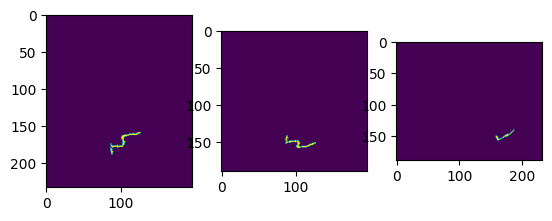

In [36]:
import matplotlib.pyplot as plt
if hasattr(phantom, 'get_fractures'):
    fractures = phantom.get_fractures()
    print(np.unique(fractures))
    f, axs = plt.subplots(1, 3)
    for dim, ax in enumerate(axs.flatten()):
        ax.imshow(fractures.max(axis=dim))

    num_fractures = fractures.astype(float)
    print(np.min(num_fractures), np.max(num_fractures))
    shape, origin, spacing, affine, array = phantom.get_nifti_info(path_mask_brain)
    phantom.save_volume_nifti(num_fractures, affine, "/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/insilicoICH/annotations/skull/NIHPD_Head_Phantom/assets/fracture.nii.gz")

In [37]:
shape, origin, spacing, affine, array = phantom.get_nifti_info(path_mask_brain)

In [38]:
array_phantom = phantom.get_CT_number_phantom()
phantom.save_volume_nifti(array_phantom, affine, "/home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/insilicoICH/annotations/skull/NIHPD_Head_Phantom/assets/phantom.nii.gz")

assign_HUs: adding fractures
Reading /home/dhaval.kadia/code/research/PedSilicoICH/InSilicoICH/src/insilicoICH/annotations/skull/NIHPD_Head_Phantom/assets/config.toml


Some simple analytical geometric lesions are included in the module `lesion_insertion`, see the help string for more details

In [39]:
# phantom.insert_lesion?

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from VITools import read_dicom, get_available_phantoms

from ipywidgets import interact, IntSlider

available_phantoms = get_available_phantoms()


def load_phantom(age, shape=None):
    '''
    load a phantom for testing
    '''
    if age < 6.5:
        return available_phantoms[f'{age} yr UNC Head'](shape=shape)
    if age < 19.0:
        return available_phantoms[f'{age} yr NIHPD Head'](shape=shape)
    if age == 38.0:
        return available_phantoms[f'{age} yr MIDA Head'](shape=shape)

In [ ]:
# from insilicoICH import load_phantom
from utils import ctshow

seed = 42
age = 6.5
display = 'brain'

phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume=40, mass_effect=False, seed=seed)

phantom_me = load_phantom(age)
phantom_me.insert_lesion('EDH', volume=40, mass_effect=True, seed=seed)
phantom_no_me_image = phantom._phantom[phantom._lesion_coords[0][0]]
phantom_me_image = phantom_me._phantom[phantom_me._lesion_coords[0][0]]

f, axs = plt.subplots(1, 3, dpi=150, gridspec_kw=dict(hspace=0, wspace=0))
ctshow(phantom._phantom[phantom._lesion_coords[0][0]], display, fig=f, ax=axs[0])
ctshow(phantom_me._phantom[phantom_me._lesion_coords[0][0]], display, fig=f, ax=axs[1])
axs[2].imshow(phantom_me_image - phantom_no_me_image, vmin=-20, vmax=20)
axs[2].set_xticks([])
axs[2].set_yticks([])

Each lesion type has its own specific method, `add_<lesion_type>`, checkout the help string of each for more details

### Intraparenchymal (round)

In [ ]:
phantom.add_round_lesion?

In [ ]:
volume = 6
intensity = 100
phantom = load_phantom(age)
phantom.resize(shape=phantom.shape)
phantom.insert_lesion('IPH', volume, intensity=intensity, complexity=3, edema=7, eccentricity=0.1, mass_effect=True) 
show_lesions(phantom)

In [ ]:
volume = 6
intensity = 100
phantom = load_phantom(age)
phantom.insert_lesion('IPH', volume=volume, intensity=intensity, complexity=3, edema=7, eccentricity=0.1, mass_effect=True) 
show_lesions(phantom)

### Subdural (SDH)

In [ ]:
volume = 20
phantom = load_phantom(age)
phantom.insert_lesion('SDH', volume, intensity=intensity, mass_effect=True) 
show_lesions(phantom, 'subdural')

### Epidural (EDH)

In [ ]:
volume = 20
phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume, intensity=intensity, mass_effect=True) 
show_lesions(phantom, 'brain')

### Multiple (TODO: ensure no overlapping of hemorrhages)

In [ ]:
seed = 32
mass_effect = True
phantom = load_phantom(age)
intensity = 100
phantom.insert_lesion('IPH', volume=3, intensity=intensity, seed=seed, mass_effect=mass_effect) 
phantom.insert_lesion('SDH', volume, intensity=intensity, seed=seed, mass_effect=mass_effect) 
phantom.insert_lesion('EDH', volume, intensity=intensity, seed=seed, mass_effect=mass_effect) 

show_lesions(phantom,'brain')

In [ ]:
phantom

In [ ]:
lesions = phantom.get_lesion_mask()
lesions.shape

`phantom._lesion_coords` is a list of (z,x,y) coordinates of the inserted lesion, you can check the `len` to see how many lesions have been inserted, thus by indexing `[0][0]` we are taking the z index of the first lesion.

In [ ]:
phantom._lesion_coords

Note that rerunning the following cell, you can keep adding lesions to a phantom

In [ ]:
from monai.transforms import RandAffine

add_positioning_augmentation = True
if add_positioning_augmentation:
    positioning_transform = RandAffine(prob=1, rotate_range = [np.pi/4, np.pi/20, np.pi/20], translate_range=[10, 10, 10], scale_range=[0.1, 0.1, 0.1], padding_mode="border")
else:
    positioning_transform = RandAffine(prob=0)

phantom.apply_transform(positioning_transform)

In [ ]:
phantom.apply_transform(positioning_transform)
show_lesions(phantom)

Note: there is some misalignment of the mask and image when there are more than 1 lesion, the first lesion mask gets transformed, but the second is untouched. This is a TODO to fix this such that all inserted lesion masks get transformed.